# CELL 1 - Installation

In [19]:
%pip install pandas
%pip install torch
%pip install torch-geometric
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install dask
%pip install pyarrow
# %pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# CELL 2 - Import

In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import SAGEConv
from torch_geometric.data import HeteroData
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import gzip
import gc
import logging
from pathlib import Path
from typing import Optional, Iterator
import pyarrow
import pyarrow.parquet as pq
import pyarrow as pa
import dask.dataframe as dd
import time
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

print(f"PyTorch  : {torch.__version__}")
print(f"PyG      : {torch_geometric.__version__}")
print(f"Device   : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch  : 2.6.0
PyG      : 2.7.0
Device   : CPU


# CELL 3 - Configuration

In [21]:
AUTH_PATH    = "/home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/auth.txt.gz"
REDTEAM_PATH = "/home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/redteam.txt.gz"
OUTPUT_DIR   = "./parsed"
CHUNKSIZE    = 500_000  # turunkan ke 200_000 jika RAM terasa berat

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

AUTH_COLUMNS = [
    "time", "src_user", "dst_user", "src_computer", "dst_computer",
    "auth_type", "logon_type", "auth_orientation", "success",
]

AUTH_TYPE_MAP   = {"NTLM": 0, "Kerberos": 1, "Negotiate": 2, "MICROSOFT_AUTHENTICATION_PACKAGE_V1_0": 3}
LOGON_TYPE_MAP  = {"Network": 0, "Interactive": 1, "Batch": 2, "Service": 3, "NetworkCleartext": 4, "RemoteInteractive": 5}
AUTH_ORIENT_MAP = {"LogOn": 0, "LogOff": 1, "TGT": 2, "AuthMap": 3}

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

print("Konfigurasi siap.")
print(f"  Auth path    : {AUTH_PATH}")
print(f"  Redteam path : {REDTEAM_PATH}")
print(f"  Output dir   : {OUTPUT_DIR}")

Konfigurasi siap.
  Auth path    : /home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/auth.txt.gz
  Redteam path : /home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/redteam.txt.gz
  Output dir   : ./parsed


# CELL 4 - Path and Size Check 

In [22]:
for p in [AUTH_PATH, REDTEAM_PATH]:
    path = Path(p)
    if path.exists():
        size_gb = path.stat().st_size / 1e9
        print(f"  OK  {path.name}  ({size_gb:.2f} GB)")
    else:
        print(f"  TIDAK DITEMUKAN: {p}")

  OK  auth.txt.gz  (7.63 GB)
  OK  redteam.txt.gz  (0.00 GB)


# CELL 5 - Build Node Map (Chunk Unique Split) 

In [ ]:
def build_node_map(auth_path, chunksize=500_000):
    log.info("Tahap 1: Scan file untuk kumpulkan node unik...")
    all_users, all_computers = set(), set()
    chunk_count = 0

    reader = pd.read_csv(
        auth_path, header=None, names=AUTH_COLUMNS, dtype=str,
        chunksize=chunksize, compression="gzip",
        na_values=["?", "", "nan", "None", "-"], low_memory=False,
    )
    for chunk in reader:
        chunk_count += 1
        all_users.update(chunk["src_user"].dropna().unique())
        all_users.update(chunk["dst_user"].dropna().unique())
        all_computers.update(chunk["src_computer"].dropna().unique())
        all_computers.update(chunk["dst_computer"].dropna().unique())
        if chunk_count % 100 == 0:
            log.info(f"  Chunk {chunk_count:,} — users: {len(all_users):,}, computers: {len(all_computers):,}")
        del chunk
        gc.collect()

    node_map = {}
    idx = 0
    for name in sorted(all_users):
        node_map[f"u_{name}"] = idx
        idx += 1
    for name in sorted(all_computers):
        node_map[f"c_{name}"] = idx
        idx += 1

    log.info(f"Selesai — {len(node_map):,} nodes total")
    return node_map

# Jalankan — ini akan lama (~30-60 menit untuk 1.6B baris)
node_map = build_node_map(AUTH_PATH, CHUNKSIZE)

# Simpan node map
node_df = pd.DataFrame(list(node_map.items()), columns=["name", "node_id"])
node_df.to_parquet(f"{OUTPUT_DIR}/node_map.parquet", index=False)
print(f"Node map disimpan: {len(node_df):,} nodes")

15:01:26 [INFO] Tahap 1: Scan file untuk kumpulkan node unik...
15:02:27 [INFO]   Chunk 100 — users: 53,179, computers: 11,572
15:03:29 [INFO]   Chunk 200 — users: 63,671, computers: 13,125
15:04:33 [INFO]   Chunk 300 — users: 70,755, computers: 14,065
15:05:35 [INFO]   Chunk 400 — users: 74,012, computers: 14,195
15:06:41 [INFO]   Chunk 500 — users: 81,024, computers: 14,747


# CELL 6 - Cleaning Attack Data Set

In [ ]:
def load_redteam_lookup(redteam_path):
    df = pd.read_csv(
        redteam_path, header=None,
        names=["time", "src_user", "src_computer", "dst_computer"],
        compression="gzip", na_values=["?", "", "None"], dtype=str,
    )
    lookup = set(zip(
        df["time"].astype(str),
        df["src_user"].fillna(""),
        df["src_computer"].fillna(""),
        df["dst_computer"].fillna(""),
    ))
    log.info(f"Redteam lookup: {len(lookup):,} events")
    return lookup

redteam_lookup = load_redteam_lookup(REDTEAM_PATH)
print(f"Redteam dimuat: {len(redteam_lookup)} events")

# Cek kenapa 715 bukan 748
df_red_raw = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
print(f"Total baris raw       : {len(df_red_raw)}")
print(f"Setelah drop duplikat : {df_red_raw.drop_duplicates().shape[0]}")
print(f"Baris dengan NaN      : {df_red_raw.isnull().any(axis=1).sum()}")
print(f"\nContoh duplikat:")
print(df_red_raw[df_red_raw.duplicated(keep=False)].head(10))

14:52:17 [INFO] Redteam lookup: 715 events


Redteam dimuat: 715 events
Total baris raw       : 749
Setelah drop duplikat : 715
Baris dengan NaN      : 0

Contoh duplikat:
       time    src_user src_computer dst_computer
323  830548  U1653@DOM1       C22409         C754
324  830548  U1653@DOM1       C22409         C754
325  830548  U1653@DOM1       C22409         C754
326  830548  U1653@DOM1       C22409         C754
327  830548  U1653@DOM1       C22409         C754
329  830578  U1653@DOM1       C22409         C754
330  830578  U1653@DOM1       C22409         C754
331  830578  U1653@DOM1       C22409         C754
332  830578  U1653@DOM1       C22409         C754
333  830580  U1653@DOM1       C22409         C754


# CELL 7 - Checking Attack Event and Attacker List

In [ ]:
df_red = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
df_red["time"] = df_red["time"].astype(int)
df_red = df_red.drop_duplicates().reset_index(drop=True)

print(f"Total attack events : {len(df_red)}")
print(f"Unique attackers    : {df_red['src_user'].nunique()}")
print(f"Unique src_computer : {df_red['src_computer'].nunique()}")
print(f"Unique dst_computer : {df_red['dst_computer'].nunique()}")
print(f"\nAttacker list:")
print(df_red.groupby("src_user")["dst_computer"].count().sort_values(ascending=False).to_string())

Total attack events : 715
Unique attackers    : 104
Unique src_computer : 4
Unique dst_computer : 301

Attacker list:
src_user
U66@DOM1        118
U3005@DOM1       36
U737@DOM1        32
U293@DOM1        31
U748@DOM1        26
U1723@DOM1       19
U3635@DOM1       18
U1653@DOM1       15
U2837@DOM1       15
U9947@DOM1       15
U4448@DOM1       14
U5087@DOM1       13
U3549@DOM1       13
U218@DOM1        13
U8601@DOM1       13
U4353@DOM1       12
U7507@DOM1       12
U342@DOM1        12
U1145@DOM1       12
U1480@DOM1       12
U162@DOM1        11
U1450@DOM1       11
U8946@DOM1       11
U2575@DOM1       10
U1048@DOM1        9
U9763@DOM1        8
U86@DOM1          8
U9263@DOM1        8
U7375@DOM1        7
U12@DOM1          6
U1592@DOM1        6
U1025@DOM1        6
U415@DOM1         6
U24@DOM1          5
U2231@DOM1        5
U1133@DOM1        5
U8777@C3388       5
U4978@DOM1        5
U1289@DOM1        5
U114@DOM1         4
U995@DOM1         4
U1600@DOM1        4
U212@DOM1         4
U1506@DOM1   

# CELL 8 - Check Attack Pattern

In [ ]:
print("Pattern Attack per attacker:\n")
for attacker in df_red["src_user"].unique():
    sub = df_red[df_red["src_user"]==attacker].sort_values("time")
    duration = sub["time"].max() - sub["time"].min()
    targets  = sub["dst_computer"].nunique()
    sources  = sub["src_computer"].nunique()
    print(f"  {attacker}")
    print(f"    Events   : {len(sub)}")
    print(f"    Duration : {duration:,} detik ({duration//3600} jam)")
    print(f"    Src comp : {sources} mesin berbeda")
    print(f"    Dst comp : {targets} target berbeda")
    print(f"    Time range: {sub['time'].min():,} - {sub['time'].max():,}")
    print()

Pattern Attack per attacker:

  U620@DOM1
    Events   : 1
    Duration : 0 detik (0 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 150,885 - 150,885

  U748@DOM1
    Events   : 26
    Duration : 313,224 detik (87 jam)
    Src comp : 2 mesin berbeda
    Dst comp : 13 target berbeda
    Time range: 151,036 - 464,260

  U6115@DOM1
    Events   : 1
    Duration : 0 detik (0 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 151,993 - 151,993

  U636@DOM1
    Events   : 2
    Duration : 332,651 detik (92 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 153,792 - 486,443

  U1723@DOM1
    Events   : 19
    Duration : 852,983 detik (236 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 7 target berbeda
    Time range: 228,642 - 1,081,625

  U737@DOM1
    Events   : 32
    Duration : 2,092,502 detik (581 jam)
    Src comp : 2 mesin berbeda
    Dst comp : 19 target berbeda
    Time range: 

# CELL 9 - Visualize Plot

/tmp/ipykernel_375015/2252951298.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hop_data = df_red.groupby("src_user").apply(
/tmp/ipykernel_375015/2252951298.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


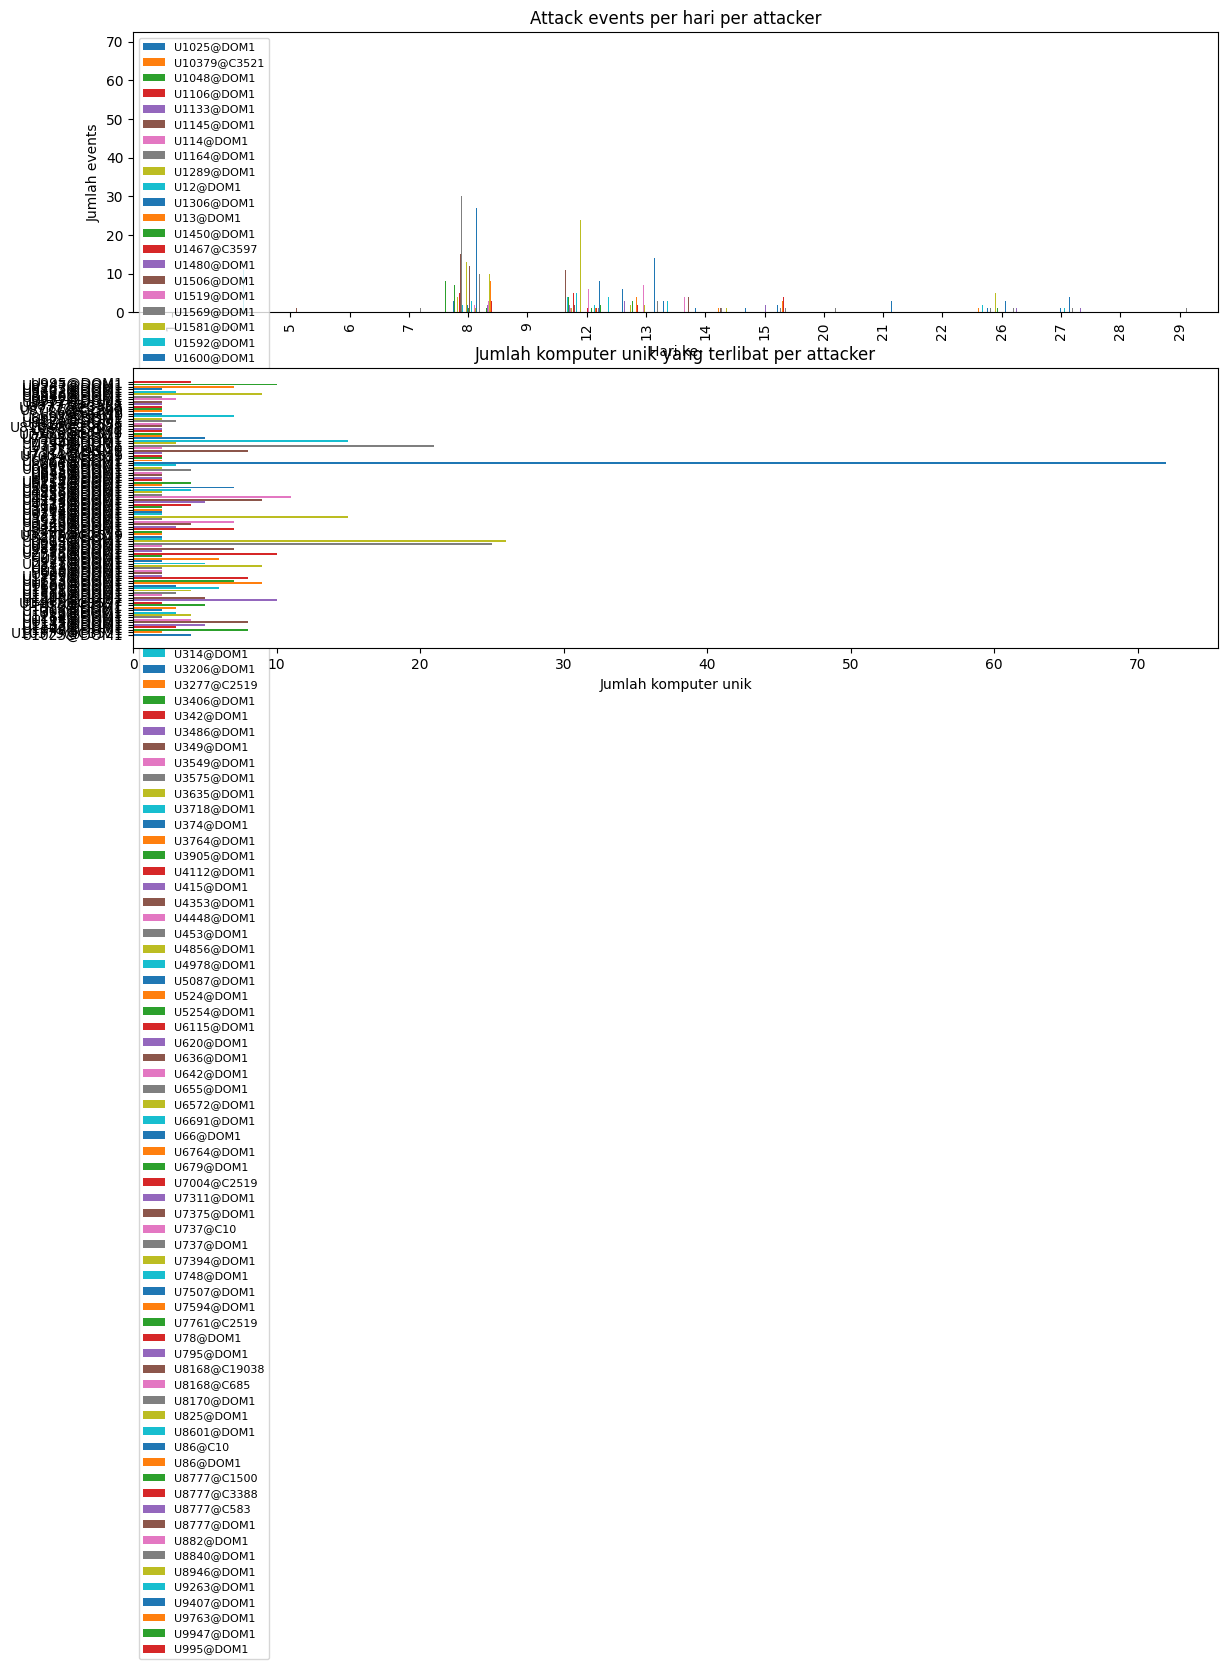

Plot disimpan ke ./parsed/redteam_analysis.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: events per attacker per hari
df_red["day"] = df_red["time"] // 86400
pivot = df_red.groupby(["day","src_user"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Attack events per hari per attacker")
axes[0].set_xlabel("Hari ke-")
axes[0].set_ylabel("Jumlah events")
axes[0].legend(fontsize=8, loc="upper left")

# Plot 2: hop count (berapa banyak komputer dikunjungi tiap attacker)
hop_data = df_red.groupby("src_user").apply(
    lambda x: x.sort_values("time")[["src_computer","dst_computer"]]
    .values.flatten()
)
for attacker, hops in hop_data.items():
    unique_hops = len(set(hops))
    axes[1].barh(attacker, unique_hops)
axes[1].set_title("Jumlah komputer unik yang terlibat per attacker")
axes[1].set_xlabel("Jumlah komputer unik")

plt.tight_layout()
plt.savefig("./parsed/redteam_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke ./parsed/redteam_analysis.png")

# CELL 10 - Variable Check

In [ ]:
# Load node_map
node_df  = pd.read_parquet("./parsed/node_map.parquet")
node_map = dict(zip(node_df["name"], node_df["node_id"]))
print(f"node_map loaded: {len(node_map):,} nodes")

# Load redteam — hanya butuh binary lookup (normal vs anomaly)
df_red = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time", "src_user", "src_computer", "dst_computer"],
    compression="gzip", dtype=str,
)
df_red["time"] = df_red["time"].astype(int)
df_red = df_red.drop_duplicates().reset_index(drop=True)

redteam_lookup = set(zip(
    df_red["time"].astype(str),
    df_red["src_user"].fillna(""),
    df_red["src_computer"].fillna(""),
    df_red["dst_computer"].fillna(""),
))
print(f"redteam_lookup loaded: {len(redteam_lookup):,} attack events")

node_map loaded: 117,634 nodes
redteam_lookup loaded: 715 attack events


# CELL 11 - Auth Process (Grouping Chunk Attack and Auth)

In [ ]:
def encode_features(chunk):
    auth_type   = chunk["auth_type"].map(AUTH_TYPE_MAP).fillna(-1).astype(np.float32)
    logon_type  = chunk["logon_type"].map(LOGON_TYPE_MAP).fillna(-1).astype(np.float32)
    auth_orient = chunk["auth_orient"].map(AUTH_ORIENT_MAP).fillna(-1).astype(np.float32)  
    success     = (chunk["success"] == "Success").astype(np.float32)
    hour        = (chunk["time"] % 86400 / 3600).astype(np.float32)
    off_hours   = ((hour < 7) | (hour > 19)).astype(np.float32)
    return np.stack([auth_type, logon_type, auth_orient, success, hour, off_hours], axis=1)

def process_auth_v2(auth_path, node_map, redteam_lookup,
                    output_dir, chunksize=500_000):

    output_dir = Path(output_dir)

    for f in sorted(output_dir.glob("edges_batch_*.parquet")) + \
             sorted(output_dir.glob("feats_batch_*.parquet")):
        f.unlink()

    for fname in ["auth_edges.parquet", "auth_feats.parquet"]:
        fpath = output_dir / fname
        if fpath.exists():
            fpath.unlink()

    reader = pd.read_csv(
        auth_path, header=None, names=AUTH_COLUMNS, dtype=str,
        chunksize=chunksize, compression="gzip",
        na_values=["?", "", "nan", "None", "-"], low_memory=False,
    )

    chunk_count  = 0
    total_edges  = 0
    total_attack = 0
    batch_edges  = []
    batch_feats  = []
    BATCH_WRITE  = 10

    redteam_keys = {"|".join(k) for k in redteam_lookup}

    for chunk in reader:
        chunk_count += 1

        chunk = chunk.dropna(subset=["src_computer", "dst_computer"])
        if len(chunk) == 0:
            continue

        chunk["time"] = pd.to_numeric(chunk["time"], errors="coerce")
        chunk = chunk.dropna(subset=["time"])
        chunk["time"] = chunk["time"].astype(np.int32)

        src_ids = ("c_" + chunk["src_computer"]).map(node_map).fillna(-1).astype(np.int32)
        dst_ids = ("c_" + chunk["dst_computer"]).map(node_map).fillna(-1).astype(np.int32)

        valid   = (src_ids != -1) & (dst_ids != -1)
        chunk   = chunk[valid].reset_index(drop=True)
        src_ids = src_ids[valid].reset_index(drop=True)
        dst_ids = dst_ids[valid].reset_index(drop=True)

        if len(chunk) == 0:
            continue

        chunk["_key"] = (chunk["time"].astype(str) + "|" +
                         chunk["src_user"].fillna("") + "|" +
                         chunk["src_computer"] + "|" +
                         chunk["dst_computer"])

        # Hanya binary label: 0=normal, 1=anomaly
        labels = chunk["_key"].isin(redteam_keys).astype(np.int8)

        n_attack = int(labels.sum())
        total_attack += n_attack
        if n_attack > 0:
            log.info(f"  Chunk {chunk_count}: {n_attack} anomaly events")

        feats = encode_features(chunk)

        # Tidak ada kolom attack_class
        batch_edges.append(pd.DataFrame({
            "src_id"   : src_ids.values,
            "dst_id"   : dst_ids.values,
            "timestamp": chunk["time"].values,
            "label"    : labels,
        }))
        batch_feats.append(pd.DataFrame(
            feats,
            columns=["feat_auth_type", "feat_logon_type", "feat_auth_orient",
                     "feat_success", "feat_hour", "feat_offhours"]
        ))
        total_edges += len(chunk)

        if chunk_count % BATCH_WRITE == 0:
            batch_idx = chunk_count // BATCH_WRITE
            pd.concat(batch_edges, ignore_index=True).to_parquet(
                output_dir / f"edges_batch_{batch_idx:04d}.parquet", index=False)
            pd.concat(batch_feats, ignore_index=True).to_parquet(
                output_dir / f"feats_batch_{batch_idx:04d}.parquet", index=False)
            batch_edges = []
            batch_feats = []
            gc.collect()
            log.info(f"  Chunk {chunk_count:,} | edges: {total_edges:,} | anomaly: {total_attack:,}")

    if batch_edges:
        batch_idx = (chunk_count // BATCH_WRITE) + 1
        pd.concat(batch_edges, ignore_index=True).to_parquet(
            output_dir / f"edges_batch_{batch_idx:04d}.parquet", index=False)
        pd.concat(batch_feats, ignore_index=True).to_parquet(
            output_dir / f"feats_batch_{batch_idx:04d}.parquet", index=False)

    log.info(f"SELESAI: {total_edges:,} edges, {total_attack:,} anomaly events")


process_auth_v2(
    auth_path      = AUTH_PATH,
    node_map       = node_map,
    redteam_lookup = redteam_lookup,
    output_dir     = OUTPUT_DIR,
    chunksize      = CHUNKSIZE,
)

KeyError: 'auth_orient'

# CELL 12 - Merge

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

def merge_batches_safe(output_dir):
    output_dir = Path(output_dir)
    edge_files = sorted(output_dir.glob("edges_batch_*.parquet"))
    feat_files = sorted(output_dir.glob("feats_batch_*.parquet"))

    log.info(f"Merge {len(edge_files)} batch files...")

    edge_writer = None
    feat_writer = None
    total_edges  = 0
    total_attack = 0

    for i, (ef, ff) in enumerate(zip(edge_files, feat_files)):
        edges = pd.read_parquet(ef)
        feats = pd.read_parquet(ff)

        sort_idx = edges["timestamp"].argsort()
        edges = edges.iloc[sort_idx].reset_index(drop=True)
        feats = feats.iloc[sort_idx].reset_index(drop=True)

        total_edges  += len(edges)
        total_attack += int(edges["label"].sum())

        e_table = pa.Table.from_pandas(edges, preserve_index=False)
        f_table = pa.Table.from_pandas(feats, preserve_index=False)

        if edge_writer is None:
            edge_writer = pq.ParquetWriter(output_dir / "auth_edges.parquet", e_table.schema)
            feat_writer = pq.ParquetWriter(output_dir / "auth_feats.parquet", f_table.schema)

        edge_writer.write_table(e_table)
        feat_writer.write_table(f_table)

        del edges, feats, e_table, f_table
        gc.collect()

        if (i + 1) % 50 == 0:
            log.info(f"  {i+1}/{len(edge_files)} batch di-merge...")

    if edge_writer:
        edge_writer.close()
        feat_writer.close()

    log.info("File final tersimpan.")

    # --- PERBAIKAN 1: Hapus file satu per satu, tidak digabung ke list besar ---
    for f in edge_files:
        f.unlink()
    for f in feat_files:
        f.unlink()
    gc.collect()
    log.info("Batch files dihapus.")

    # --- PERBAIKAN 2: Hitung statistik dari variabel, TIDAK baca file lagi ---
    print(f"\nHasil akhir:")
    print(f"  Total edges  : {total_edges:,}")
    print(f"  Attack (1)   : {total_attack:,}")
    print(f"  Normal (0)   : {total_edges - total_attack:,}")
    print(f"  Attack ratio : {total_attack / max(total_edges, 1):.8%}")
    print(f"\n  File: {output_dir}/auth_edges.parquet")
    print(f"  File: {output_dir}/auth_feats.parquet")
    log.info("Merge selesai.")

merge_batches_safe(OUTPUT_DIR)

09:32:58 [INFO] Merge 211 batch files...


09:33:54 [INFO]   50/211 batch di-merge...
09:34:49 [INFO]   100/211 batch di-merge...
09:35:44 [INFO]   150/211 batch di-merge...
09:36:39 [INFO]   200/211 batch di-merge...
09:36:50 [INFO] File final tersimpan.
09:36:51 [INFO] Batch files dihapus.
09:36:51 [INFO] Merge selesai.



Hasil akhir:
  Total edges  : 1,051,430,459
  Attack (1)   : 702
  Normal (0)   : 1,051,429,757
  Attack ratio : 0.00006677%

  File: parsed/auth_edges.parquet
  File: parsed/auth_feats.parquet


# CELL 13 - Check Parsed Folder

In [ ]:
import os

# Cek isi folder parsed
print("=== Isi folder ./parsed/ ===")
parsed = Path("./parsed")
if parsed.exists():
    files = sorted(parsed.iterdir())
    for f in files:
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name:<45} {size_mb:>10.1f} MB")
else:
    print("Folder ./parsed/ tidak ditemukan!")

print(f"\nTotal files: {len(list(parsed.iterdir()))}")

=== Isi folder ./parsed/ ===
  attacker_profiles.parquet                            0.0 MB
  auth_edges.parquet                                5418.3 MB
  auth_feats.parquet                                1141.8 MB
  node_map.parquet                                     1.4 MB
  redteam_analysis.png                                 0.4 MB

Total files: 5


# CELL 14 - Checking File Path

In [ ]:
# Cek juga di mana notebook ini berjalan
print(f"Working directory: {os.getcwd()}")

# Cek apakah ada folder lain yang berisi batch files
for root, dirs, files in os.walk("."):
    for f in files:
        if "batch" in f or "edges" in f or "feats" in f or "node_map" in f:
            full = os.path.join(root, f)
            size_mb = os.path.getsize(full) / 1e6
            print(f"  {full:<60} {size_mb:.1f} MB")

Working directory: /home/adriel/Desktop/Coding/LogNet
  ./parsed/auth_feats.parquet                                  1141.8 MB
  ./parsed/auth_edges.parquet                                  5418.3 MB
  ./parsed/node_map.parquet                                    1.4 MB


# CELL 15 - Categorizing Attack

In [ ]:
import pyarrow.parquet as pq

# Baca statistik tanpa load semua ke RAM
pf = pq.ParquetFile("./parsed/auth_edges.parquet")

total_edges  = 0
total_attack = 0
ts_min = float('inf')
ts_max = float('-inf')

# Baca per batch kecil 5 juta baris
for batch in pf.iter_batches(batch_size=5_000_000, columns=["timestamp", "label"]):
    df = batch.to_pandas()
    total_edges  += len(df)
    total_attack += int(df["label"].sum())
    ts_min = min(ts_min, int(df["timestamp"].min()))
    ts_max = max(ts_max, int(df["timestamp"].max()))
    del df
    gc.collect()

print(f"Total edges  : {total_edges:,}")
print(f"Attack (1)   : {total_attack:,}")
print(f"Normal (0)   : {total_edges - total_attack:,}")
print(f"Attack ratio : {total_attack / max(total_edges,1):.8%}")
print(f"Time range   : {ts_min:,} - {ts_max:,}")

Total edges  : 1,051,430,459
Attack (1)   : 702
Normal (0)   : 1,051,429,757
Attack ratio : 0.00006677%
Time range   : 1 - 5,011,199


# CELL 16 - Checking Edges

In [ ]:
pf = pq.ParquetFile("./parsed/auth_edges.parquet")

total_edges  = 0
total_attack = 0

for batch in pf.iter_batches(batch_size=5_000_000, columns=["label"]):
    df = batch.to_pandas()
    total_edges  += len(df)
    total_attack += int(df["label"].sum())
    del df
    gc.collect()

print(f"Total edges  : {total_edges:,}")
print(f"Anomaly (1)  : {total_attack:,}")
print(f"Normal  (0)  : {total_edges - total_attack:,}")
print(f"Anomaly ratio: {total_attack / max(total_edges, 1):.8%}")

NameError: name 'pq' is not defined

# CELL 17 - Load Split Config + Constanta

In [ ]:
pf = pq.ParquetFile("./parsed/auth_edges.parquet")
 
ts_min     = float('inf')
ts_max     = float('-inf')
total_rows = 0
TS_MIN = ts_min
TS_MAX = ts_max
 
for batch in pf.iter_batches(batch_size=5_000_000, columns=["timestamp"]):
    df = batch.to_pandas()
    ts_min = min(ts_min, int(df["timestamp"].min()))
    ts_max = max(ts_max, int(df["timestamp"].max()))
    total_rows += len(df)
    del df
    gc.collect()
 
TS_TRAIN_END = ts_min + 7  * 86400
TS_VAL_END   = ts_min + 15 * 86400
 
print(f"ts_min     : {ts_min:,}")
print(f"ts_max     : {ts_max:,}")
print(f"total rows : {total_rows:,}")
 
pd.DataFrame([{
    "ts_min"       : ts_min,
    "ts_max"       : ts_max,
    "ts_train_end" : TS_TRAIN_END,
    "ts_val_end"   : TS_VAL_END,
}]).to_parquet("./parsed/split_config.parquet", index=False)
 
NUM_NODES     = len(node_map)
MEMORY_DIM    = 64
EMBED_DIM     = 64
EDGE_FEAT_DIM = 6
# Bug 6 fix: NUM_CLASSES = 3 (hanya attack class: Recon, Lateral, Persistence)
# Class head tidak perlu tahu tentang "Normal" — normal events tidak masuk class head
NUM_CLASSES   = 3
WINDOW_SIZE   = 86_400
BATCH_SIZE    = 2_048
LR            = 1e-3
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Bug 5 fix: best_thresh didefinisikan sebagai global default
# Akan di-overwrite oleh threshold search di Cell 30 jika test set punya 2 kelas
best_thresh = 0.5
 
print(f"\nKonstanta model siap. Device: {DEVICE}")
print(f"NUM_CLASSES = {NUM_CLASSES}  (1=Recon, 2=Lateral, 3=Persistence)")
print(f"best_thresh default = {best_thresh}  (akan di-update setelah eval)")

ts_min     : 1
ts_max     : 5,011,199
total rows : 1,051,430,459

Konstanta model siap. Device: cpu
NUM_CLASSES = 3  (1=Recon, 2=Lateral, 3=Persistence)
best_thresh default = 0.5  (akan di-update setelah eval)


# CELL 18 - Temporal Graph Network Architecture

In [ ]:
class MemoryModule(nn.Module):
    def __init__(self, num_nodes, memory_dim):
        super().__init__()
        self.memory_dim = memory_dim
        self.register_buffer("memory",      torch.zeros(num_nodes, memory_dim))
        self.register_buffer("last_update", torch.zeros(num_nodes, dtype=torch.long))
        self.gru = nn.GRUCell(memory_dim, memory_dim)

    def reset_memory(self):
        self.memory.zero_()
        self.last_update.zero_()

    def get_memory(self, node_ids):
        return self.memory[node_ids.cpu()].to(node_ids.device)

    def update_memory(self, node_ids, messages):
        node_ids_cpu = node_ids.cpu()
        old_mem = self.memory[node_ids_cpu].to(messages.device)
        new_mem = self.gru(messages, old_mem)
        self.memory[node_ids_cpu] = new_mem.detach().cpu()


class MessageModule(nn.Module):
    def __init__(self, memory_dim, edge_feat_dim, message_dim):
        super().__init__()
        input_dim = memory_dim * 2 + edge_feat_dim + 1
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, message_dim),
        )

    def forward(self, src_mem, dst_mem, edge_feat, delta_t):
        delta_t = delta_t.unsqueeze(1).float()
        x = torch.cat([src_mem, dst_mem, edge_feat, delta_t], dim=1)
        return self.mlp(x)


class EmbeddingModule(nn.Module):
    def __init__(self, memory_dim, embed_dim):
        super().__init__()
        self.sage     = SAGEConv(memory_dim, embed_dim)
        self.norm     = nn.LayerNorm(embed_dim)
        self.fallback = nn.Linear(memory_dim, embed_dim, bias=False)

    def forward(self, x, edge_index):
        if edge_index.shape[1] == 0:
            return F.relu(self.fallback(x))
        return self.norm(F.relu(self.sage(x, edge_index)))


class TGN(nn.Module):
    def __init__(self, num_nodes, memory_dim=64, message_dim=64,
                 embed_dim=64, edge_feat_dim=6, dropout=0.3):
        super().__init__()
        self.num_nodes  = num_nodes
        self.memory_dim = memory_dim
        self.memory     = MemoryModule(num_nodes, memory_dim)
        self.message    = MessageModule(memory_dim, edge_feat_dim, message_dim)
        self.embedding  = EmbeddingModule(memory_dim, embed_dim)

        # Hanya satu head: anomaly score
        self.anomaly_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )

    def forward(self, src_ids, dst_ids, edge_feat, timestamps, edge_index):
        all_active     = torch.unique(torch.cat([src_ids, dst_ids]))
        all_active_cpu = all_active.cpu()

        global_to_local = torch.full((self.num_nodes,), -1, dtype=torch.long)
        global_to_local[all_active_cpu] = torch.arange(len(all_active), dtype=torch.long)
        global_to_local = global_to_local.to(src_ids.device)

        src_ei, dst_ei = edge_index[0], edge_index[1]
        src_l_ei = global_to_local[src_ei]
        dst_l_ei = global_to_local[dst_ei]
        valid_ei = (src_l_ei >= 0) & (dst_l_ei >= 0)
        local_ei = torch.stack([src_l_ei[valid_ei], dst_l_ei[valid_ei]], dim=0)

        sub_memory = self.memory.memory[all_active_cpu].to(src_ids.device)
        src_mem    = self.memory.get_memory(src_ids)
        dst_mem    = self.memory.get_memory(dst_ids)
        last_t     = self.memory.last_update[src_ids].float()
        delta_t    = (timestamps.float() - last_t).clamp(min=0)
        messages   = self.message(src_mem, dst_mem, edge_feat, delta_t)

        self.memory.update_memory(src_ids, messages)
        self.memory.update_memory(dst_ids, messages)
        self.memory.last_update[src_ids] = timestamps
        self.memory.last_update[dst_ids] = timestamps

        node_emb  = self.embedding(sub_memory, local_ei)
        src_local = global_to_local[src_ids]
        dst_local = global_to_local[dst_ids]
        edge_emb  = torch.cat([node_emb[src_local], node_emb[dst_local]], dim=1)

        # Return langsung anomaly score — tidak ada class logit
        return self.anomaly_head(edge_emb).squeeze(1)

    def detach_memory(self):
        self.memory.memory = self.memory.memory.detach()

# CELL 19 - Initialize Model

In [ ]:
n_train_attack = 0
n_train_normal = 0
for batch in pq.ParquetFile("./parsed/auth_edges_sampled.parquet").iter_batches(
        batch_size=5_000_000, columns=["timestamp","label"]):
    df = batch.to_pandas()
    mask = df["timestamp"] < TS_TRAIN_END
    n_train_attack += int(df.loc[mask, "label"].sum())
    n_train_normal += int((df.loc[mask, "label"] == 0).sum())

model = TGN(
    num_nodes     = NUM_NODES,
    memory_dim    = MEMORY_DIM,
    message_dim   = MEMORY_DIM,
    embed_dim     = EMBED_DIM,
    edge_feat_dim = EDGE_FEAT_DIM,
    dropout       = 0.3,
).to(DEVICE)

# Pos weight dari proporsi training
pos_weight        = torch.tensor([n_train_normal / max(n_train_attack, 1)], device=DEVICE)
criterion_anomaly = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5  # mode=max karena monitor AUROC
)

best_thresh = 0.5
print(f"Model siap: {sum(p.numel() for p in model.parameters()):,} params")
print(f"pos_weight: {pos_weight.item():.1f}x")

NUM_NODES: 117,634
Train normal : 11,369,935
Train attack : 49
pos_weight   : 232039.5x
Model siap di  : cpu
Total parameter: 67,076
best_thresh    : 0.5  (default, akan di-update setelah eval)


# CELL 20 - Stratified Temporal Sampling

In [ ]:
# normal_ratio dinaikkan ke 0.10 karena:
# - Train window pendek (7 hari), perlu lebih banyak data per hari
# - Total dataset tetap manageable

def create_stratified_sample_v2(
    output_dir    = "./parsed",
    normal_ratio  = 0.10,    # 10% normal — lebih tinggi dari sebelumnya
    window_size   = 86_400,
    ts_train_end  = TS_TRAIN_END,
    ts_val_end    = TS_VAL_END,
):
    """
    Versi 2: ratio adaptif per split.
    - Train (hari 0–6)  : 10% normal — lebih representatif di window pendek
    - Val   (hari 7–14) : 5%  normal — cukup untuk evaluasi
    - Test  (hari 15–57): 2%  normal — hemat RAM, fokus generalisasi
    """
    pf_e = pq.ParquetFile(f"{output_dir}/auth_edges.parquet")
    pf_f = pq.ParquetFile(f"{output_dir}/auth_feats.parquet")

    edge_writer = None
    feat_writer = None
    total_attack_kept = 0
    total_normal_kept = 0

    # Ratio adaptif per split
    def get_ratio(ts):
        if ts < ts_train_end:
            return 0.10   # train
        elif ts < ts_val_end:
            return 0.05   # val
        else:
            return 0.02   # test

    for batch_e, batch_f in zip(
        pf_e.iter_batches(batch_size=5_000_000),
        pf_f.iter_batches(batch_size=5_000_000),
    ):
        df_e = batch_e.to_pandas().reset_index(drop=True)
        df_f = batch_f.to_pandas().reset_index(drop=True)

        attack_mask = df_e["label"] == 1
        attack_idx  = df_e.index[attack_mask].tolist()
        normal_idx  = df_e.index[~attack_mask].tolist()

        # Sample normal dengan ratio adaptif per hari
        normal_e = df_e.loc[normal_idx].copy()
        normal_e["_day"]   = normal_e["timestamp"] // window_size
        normal_e["_ratio"] = normal_e["timestamp"].apply(get_ratio)

        sampled_parts = []
        for day, grp in normal_e.groupby("_day"):
            ratio = grp["_ratio"].iloc[0]
            s = grp.sample(frac=ratio, random_state=42)
            sampled_parts.append(s)

        if sampled_parts:
            sampled_normal = pd.concat(sampled_parts)
            sampled_idx    = sampled_normal.index.tolist()
        else:
            sampled_idx = []

        if len(sampled_idx) == 0 and len(attack_idx) == 0:
            del df_e, df_f, normal_e
            gc.collect()
            continue

        keep_idx   = attack_idx + sampled_idx
        sort_order = df_e.loc[keep_idx].sort_values("timestamp").index

        combined_e = df_e.loc[sort_order].reset_index(drop=True)
        combined_f = df_f.loc[sort_order].reset_index(drop=True)

        n_attack = int((combined_e["label"] == 1).sum())
        n_normal = int((combined_e["label"] == 0).sum())
        total_attack_kept += n_attack
        total_normal_kept += n_normal

        e_table = pa.Table.from_pandas(combined_e, preserve_index=False)
        f_table = pa.Table.from_pandas(combined_f, preserve_index=False)

        if edge_writer is None:
            edge_writer = pq.ParquetWriter(
                f"{output_dir}/auth_edges_sampled.parquet", e_table.schema)
            feat_writer = pq.ParquetWriter(
                f"{output_dir}/auth_feats_sampled.parquet", f_table.schema)

        edge_writer.write_table(e_table)
        feat_writer.write_table(f_table)

        del df_e, df_f, combined_e, combined_f, normal_e
        gc.collect()

    if edge_writer:
        edge_writer.close()
        feat_writer.close()

    total = total_attack_kept + total_normal_kept
    print(f"\nSampling selesai (adaptive ratio):")
    print(f"  Attack events : {total_attack_kept:,}  (target: ~702)")
    print(f"  Normal events : {total_normal_kept:,}")
    print(f"  Total         : {total:,}")
    print(f"  Attack ratio  : {total_attack_kept/max(total,1):.4%}")

    if total_attack_kept < 700:
        print(f"\n  WARNING: {702 - total_attack_kept} attack events hilang!")


# Hapus file sampled lama
for fname in ["auth_edges_sampled.parquet", "auth_feats_sampled.parquet"]:
    fpath = Path(f"./parsed/{fname}")
    if fpath.exists():
        fpath.unlink()
        print(f"File lama dihapus: {fname}")

create_stratified_sample_v2()

File lama dihapus: auth_edges_sampled.parquet
File lama dihapus: auth_feats_sampled.parquet

Sampling selesai (adaptive ratio):
  Attack events : 702  (target: ~702)
  Normal events : 34,578,577
  Total         : 34,579,279
  Attack ratio  : 0.0020%


# CELL 21 - Pre-Index Training (untuk file sampled)

In [ ]:
pf = pq.ParquetFile("./parsed/auth_edges_sampled.parquet")
metadata = pf.metadata

print(f"Jumlah row groups : {metadata.num_row_groups}")
print(f"Total baris       : {metadata.num_rows}")
print(f"Window size       : {WINDOW_SIZE:,} detik (1 hari)")

batch_index = []

for rg_num in range(metadata.num_row_groups):
    rg = metadata.row_group(rg_num)

    ts_col_idx = None
    for i in range(rg.num_columns):
        if rg.column(i).path_in_schema == "timestamp":
            ts_col_idx = i
            break

    if ts_col_idx is not None and rg.column(ts_col_idx).statistics is not None:
        stats    = rg.column(ts_col_idx).statistics
        ts_min_v = int(stats.min)
        ts_max_v = int(stats.max)
    else:
        df_ts    = pf.read_row_group(rg_num, columns=["timestamp"]).to_pandas()
        ts_min_v = int(df_ts["timestamp"].min())
        ts_max_v = int(df_ts["timestamp"].max())
        del df_ts
        gc.collect()

    batch_index.append({
        "rg_num"    : rg_num,
        "row_count" : rg.num_rows,
        "ts_min"    : ts_min_v,
        "ts_max"    : ts_max_v,
    })

batch_index_df = pd.DataFrame(batch_index)
batch_index_df.to_parquet("./parsed/batch_index.parquet", index=False)

print(f"\nIndex dibangun: {len(batch_index_df)} row groups")
print(batch_index_df.head(10).to_string())

Jumlah row groups : 211
Total baris       : 34579279
Window size       : 86,400 detik (1 hari)

Index dibangun: 211 row groups
   rg_num  row_count  ts_min  ts_max
0       0     500000       1   34010
1       1     500000   34011   54657
2       2     500000   54657   81718
3       3     500000   81718  112252
4       4     500000  112252  132023
5       5     500004  132023  152803
6       6     500005  152803  183399
7       7     500001  183400  210247
8       8     500012  210248  234350
9       9     500001  234350  266325


# CELL 22 - Load Window

In [ ]:
def load_window_fast(ts_start, ts_end, batch_size=BATCH_SIZE):
    pf_e = pq.ParquetFile("./parsed/auth_edges_sampled.parquet")
    pf_f = pq.ParquetFile("./parsed/auth_feats_sampled.parquet")

    relevant = batch_index_df[
        (batch_index_df["ts_max"] >= ts_start) &
        (batch_index_df["ts_min"] <  ts_end)
    ]
    if relevant.empty:
        return

    for _, row in relevant.iterrows():
        rg_num = int(row["rg_num"])
        df_e = pf_e.read_row_group(rg_num).to_pandas()
        df_f = pf_f.read_row_group(rg_num).to_pandas()

        mask = (df_e["timestamp"] >= ts_start) & (df_e["timestamp"] < ts_end)
        df_e = df_e[mask].reset_index(drop=True)
        df_f = df_f[mask].reset_index(drop=True)

        if len(df_e) == 0:
            del df_e, df_f
            continue

        window_ei = torch.stack([
            torch.tensor(df_e["src_id"].values, dtype=torch.long),
            torch.tensor(df_e["dst_id"].values, dtype=torch.long),
        ], dim=0).to(DEVICE)

        for start in range(0, len(df_e), batch_size):
            end = min(start + batch_size, len(df_e))
            be_ = df_e.iloc[start:end]
            bf_ = df_f.iloc[start:end]

            yield (
                torch.tensor(be_["src_id"].values,    dtype=torch.long).to(DEVICE),
                torch.tensor(be_["dst_id"].values,    dtype=torch.long).to(DEVICE),
                torch.tensor(bf_.values,              dtype=torch.float32).to(DEVICE),
                torch.tensor(be_["timestamp"].values, dtype=torch.long).to(DEVICE),
                torch.tensor(be_["label"].values,     dtype=torch.long).to(DEVICE),
                window_ei,
            )

        del df_e, df_f, window_ei
        gc.collect()

# CELL 23 - Training Estimation Loop

In [ ]:
n_train_windows = (TS_TRAIN_END - TS_MIN) // WINDOW_SIZE 
n_val_windows   = (TS_VAL_END - TS_TRAIN_END) // WINDOW_SIZE
 
print(f"Train windows : {n_train_windows} hari")
print(f"Val windows   : {n_val_windows} hari")
 
pf_bench = pq.ParquetFile("./parsed/auth_edges_sampled.parquet")
total_rows_bench = pf_bench.metadata.num_rows
avg_edges_per_window = total_rows_bench / (n_train_windows + n_val_windows)
avg_batches_per_window = avg_edges_per_window / BATCH_SIZE
 
print(f"\nTotal rows sampled  : {total_rows_bench:,}")
print(f"Avg edges/window    : {avg_edges_per_window:,.0f}")
print(f"Avg batches/window  : {avg_batches_per_window:.1f}")
 
model.train()
model.memory.reset_memory()
 
batch_times = []

for src, dst, feat, ts, lbl, ei in load_window_fast(TS_MIN, TS_MIN + WINDOW_SIZE):
    t0 = time.time()
    with torch.set_grad_enabled(True):
        for src, dst, feat, ts, lbl, ei in load_window_fast(TS_MIN, TS_MIN + WINDOW_SIZE):
            t0 = time.time()
            with torch.set_grad_enabled(True):
                ano_logit = model(src, dst, feat, ts, ei)   # ← hapus cls_logit
                loss = criterion_anomaly(ano_logit, lbl.float())  # ← tambah .float()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            model.detach_memory()
            batch_times.append(time.time() - t0)
            if len(batch_times) >= 5:
                break
        loss = criterion_anomaly(ano_logit, lbl)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.detach_memory()
    batch_times.append(time.time() - t0)
    if len(batch_times) >= 5:
        break
 
if batch_times:
    avg_batch_sec = sum(batch_times) / len(batch_times)
    total_batches_train = int(avg_batches_per_window * n_train_windows)
    total_batches_val   = int(avg_batches_per_window * n_val_windows)
    sec_per_epoch = (total_batches_train + total_batches_val) * avg_batch_sec
 
    print(f"\nBenchmark ({len(batch_times)} batch):")
    print(f"  Avg per batch   : {avg_batch_sec:.3f} detik")
    print(f"  Total batch/epoch (train+val): {total_batches_train + total_batches_val:,}")
    print(f"\nEstimasi waktu:")
    print(f"  Per epoch       : {sec_per_epoch/60:.1f} menit")
    print(f"  10 epoch (max)  : {sec_per_epoch*10/3600:.1f} jam")
    print(f"  Early stop ~4ep : {sec_per_epoch*4/3600:.1f} jam")
    print(f"\nDevice          : {DEVICE}")
    if str(DEVICE) == "cpu":
        print("  PERINGATAN: CPU training. Pertimbangkan GPU atau aktifkan CUDA.")

Train windows : 7 hari
Val windows   : 8 hari

Total rows sampled  : 34,579,279
Avg edges/window    : 2,305,285
Avg batches/window  : 1125.6

Benchmark (5 batch):
  Avg per batch   : 0.230 detik
  Total batch/epoch (train+val): 16,884

Estimasi waktu:
  Per epoch       : 64.6 menit
  10 epoch (max)  : 10.8 jam
  Early stop ~4ep : 4.3 jam

Device          : cpu
  PERINGATAN: CPU training. Pertimbangkan GPU atau aktifkan CUDA.


# CELL 24 - Train Split Attack Check

Statistik per split:
       n_days      avg_rows  min_rows  max_rows  total_atk
split                                                     
test       43  3.686011e+05    262776    500507         79
train       7  1.624282e+06   1339814   1938161         49
val         8  9.199321e+05    700627   1040440        574

Hari tanpa attack : 40 dari 58 hari
Hari dengan attack: 18 hari


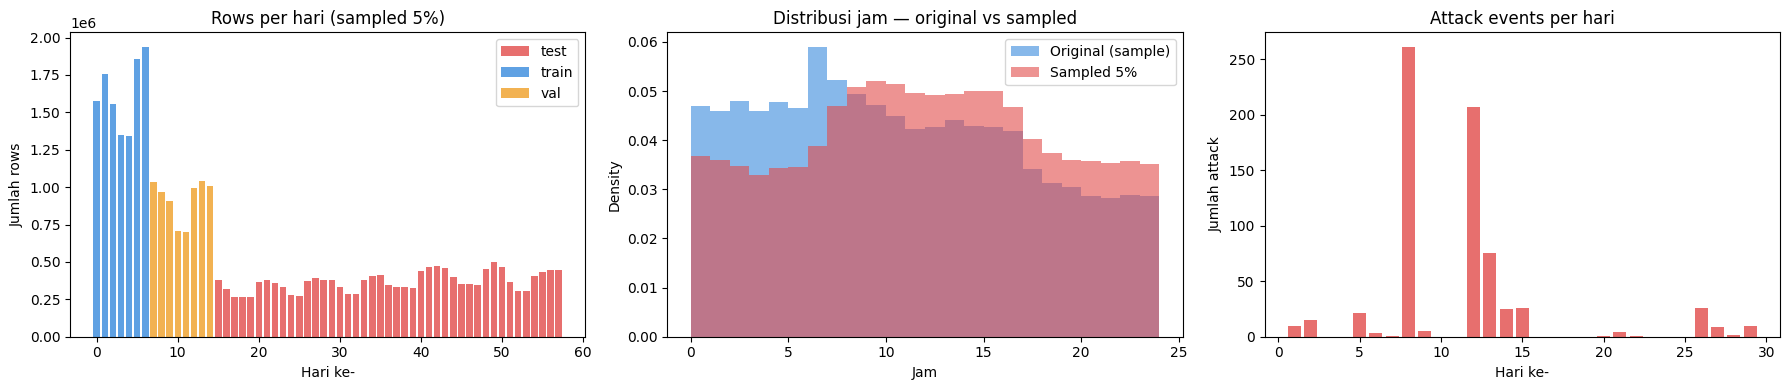


KESIMPULAN REPRESENTASI SAMPLING
Total original    : 1,051,430,459
Total sampled     : 34,579,279
Actual ratio      : 3.289%
Attack di sampled : 702 / 702 (100.0%)

Jika ratio diturunkan ke 0.3%:
  Estimasi rows   : 3,154,291
  Attack ratio    : 0.0223%  (vs sekarang 0.0020%)
  Avg rows/hari   : 54,384  (vs sekarang 596,194)


In [ ]:
# Analisis representasi sampling sebelum memutuskan ratio

# 1. Cek distribusi temporal — apakah tiap hari terwakili?
pf = pq.ParquetFile("./parsed/auth_edges_sampled.parquet")
daily_counts = {}
daily_attacks = {}

for batch in pf.iter_batches(batch_size=5_000_000,
                              columns=["timestamp","label"]):
    df = batch.to_pandas()
    df["day"] = df["timestamp"] // 86400
    for day, grp in df.groupby("day"):
        daily_counts[day]  = daily_counts.get(day, 0)  + len(grp)
        daily_attacks[day] = daily_attacks.get(day, 0) + int(grp["label"].sum())
    del df; gc.collect()

days_df = pd.DataFrame({
    "day"    : list(daily_counts.keys()),
    "n_rows" : list(daily_counts.values()),
    "n_atk"  : list(daily_attacks.values()),
}).sort_values("day").reset_index(drop=True)

days_df["split"] = "train"
days_df.loc[days_df["day"] >= TS_TRAIN_END // 86400, "split"] = "val"
days_df.loc[days_df["day"] >= TS_VAL_END   // 86400, "split"] = "test"

print("Statistik per split:")
print(days_df.groupby("split").agg(
    n_days    = ("day",   "count"),
    avg_rows  = ("n_rows","mean"),
    min_rows  = ("n_rows","min"),
    max_rows  = ("n_rows","max"),
    total_atk = ("n_atk", "sum"),
).to_string())

print(f"\nHari tanpa attack : {(days_df['n_atk']==0).sum()} dari {len(days_df)} hari")
print(f"Hari dengan attack: {(days_df['n_atk']>0).sum()} hari")

# 2. Cek distribusi fitur — apakah 5% sampling menjaga distribusi?
# Bandingkan distribusi feat_hour antara original vs sampled
pf_orig = pq.ParquetFile("./parsed/auth_edges.parquet")
pf_samp = pq.ParquetFile("./parsed/auth_edges_sampled.parquet")

# Sample kecil dari original untuk perbandingan
orig_hours = []
for batch in pf_orig.iter_batches(batch_size=5_000_000,
                                   columns=["feat_hour"] 
                                   if "feat_hour" in pf_orig.schema_arrow.names 
                                   else ["timestamp"]):
    df = batch.to_pandas()
    if "feat_hour" not in df.columns:
        df["feat_hour"] = (df["timestamp"] % 86400) / 3600
    orig_hours.extend(df["feat_hour"].sample(min(50000, len(df)),
                                              random_state=42).tolist())
    del df; gc.collect()
    if len(orig_hours) >= 200000:
        break

samp_hours = []
for batch in pf_samp.iter_batches(batch_size=5_000_000,
                                   columns=["timestamp"]):
    df = batch.to_pandas()
    df["feat_hour"] = (df["timestamp"] % 86400) / 3600
    samp_hours.extend(df["feat_hour"].sample(min(50000, len(df)),
                                              random_state=42).tolist())
    del df; gc.collect()
    if len(samp_hours) >= 200000:
        break

# Plot perbandingan distribusi
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: rows per hari per split
colors = {"train":"#378ADD", "val":"#EF9F27", "test":"#E24B4A"}
for split, grp in days_df.groupby("split"):
    axes[0].bar(grp["day"], grp["n_rows"], 
                color=colors[split], label=split, alpha=0.8, width=0.8)
axes[0].set_title("Rows per hari (sampled 5%)")
axes[0].set_xlabel("Hari ke-")
axes[0].set_ylabel("Jumlah rows")
axes[0].legend()

# Plot 2: distribusi jam (original vs sampled)
axes[1].hist(orig_hours, bins=24, density=True, alpha=0.6,
             label="Original (sample)", color="#378ADD")
axes[1].hist(samp_hours, bins=24, density=True, alpha=0.6,
             label="Sampled 5%", color="#E24B4A")
axes[1].set_title("Distribusi jam — original vs sampled")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Density")
axes[1].legend()

# Plot 3: attack events per hari
atk_days = days_df[days_df["n_atk"] > 0]
axes[2].bar(atk_days["day"], atk_days["n_atk"],
            color="#E24B4A", alpha=0.8)
axes[2].set_title("Attack events per hari")
axes[2].set_xlabel("Hari ke-")
axes[2].set_ylabel("Jumlah attack")

plt.tight_layout()
plt.savefig("./parsed/sampling_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Kesimpulan representasi
print("\n" + "="*60)
print("KESIMPULAN REPRESENTASI SAMPLING")
print("="*60)

total_samp   = days_df["n_rows"].sum()
total_orig   = 0
for batch in pf_orig.iter_batches(batch_size=5_000_000, columns=["timestamp"]):
    total_orig += len(batch)
    del batch

actual_ratio = total_samp / total_orig * 100
print(f"Total original    : {total_orig:,}")
print(f"Total sampled     : {total_samp:,}")
print(f"Actual ratio      : {actual_ratio:.3f}%")
print(f"Attack di sampled : {days_df['n_atk'].sum()} / 702 ({days_df['n_atk'].sum()/702*100:.1f}%)")
print(f"\nJika ratio diturunkan ke 0.3%:")
est_rows = total_orig * 0.003
print(f"  Estimasi rows   : {est_rows:,.0f}")
print(f"  Attack ratio    : {702/est_rows*100:.4f}%  (vs sekarang {702/total_samp*100:.4f}%)")
print(f"  Avg rows/hari   : {est_rows/58:,.0f}  (vs sekarang {total_samp/58:,.0f})")

# CELL 25 - Distribution Attack Check

In [ ]:
# Cek distribusi attack per hari secara detail

pf = pq.ParquetFile("./parsed/auth_edges.parquet")
atk_by_day = {}

for batch in pf.iter_batches(batch_size=5_000_000,
                              columns=["timestamp","label"]):
    df = batch.to_pandas()
    df["day"] = df["timestamp"] // 86400
    for day, grp in df.groupby("day"):
        atk_by_day[day] = atk_by_day.get(day, 0) + int(grp["label"].sum())
    del df; gc.collect()

atk_df = pd.DataFrame({
    "day"   : list(atk_by_day.keys()),
    "n_atk" : list(atk_by_day.values()),
}).sort_values("day").reset_index(drop=True)

attack_days = atk_df[atk_df["n_atk"] > 0]
print("Hari yang mengandung attack:")
print(attack_days.to_string())

print(f"\nHari attack pertama : hari ke-{attack_days['day'].min()}")
print(f"Hari attack terakhir: hari ke-{attack_days['day'].max()}")
print(f"Total hari dataset  : {atk_df['day'].max() + 1}")
print(f"\nTS_TRAIN_END = hari ke-{TS_TRAIN_END // 86400}")
print(f"TS_VAL_END   = hari ke-{TS_VAL_END   // 86400}")
print(f"TS_MAX       = hari ke-{TS_MAX        // 86400}")

Hari yang mengandung attack:
    day  n_atk
1     1     10
2     2     15
5     5     21
6     6      3
7     7      1
8     8    261
9     9      5
12   12    207
13   13     75
14   14     25
15   15     26
20   20      1
21   21      4
22   22      1
26   26     26
27   27      9
28   28      2
29   29     10

Hari attack pertama : hari ke-1
Hari attack terakhir: hari ke-29
Total hari dataset  : 58

TS_TRAIN_END = hari ke-7
TS_VAL_END   = hari ke-15
TS_MAX       = hari ke-57


# CELL 26 - Training Loop

In [ ]:
EPOCHS         = 10
PATIENCE       = 3
best_val_auroc = 0.0
patience_ctr   = 0

def run_epoch(split="train", epoch=0):
    is_train = (split == "train")
    model.train() if is_train else model.eval()

    if is_train:
        model.memory.reset_memory()

    ts_start, ts_end = {
        "train": (TS_MIN, TS_TRAIN_END),
        "val"  : (TS_TRAIN_END, TS_VAL_END),
        "test" : (TS_VAL_END, TS_MAX),
    }[split]

    total_loss    = 0.0
    n_batches     = 0
    all_labels    = []
    all_probs     = []
    t_epoch       = time.time()
    windows       = list(range(ts_start, ts_end, WINDOW_SIZE))

    for w_idx, w_start in enumerate(windows):
        for src, dst, feat, ts, lbl, ei in load_window_fast(w_start, w_start + WINDOW_SIZE):

            with torch.set_grad_enabled(is_train):
                ano_logit = model(src, dst, feat, ts, ei)
                loss      = criterion_anomaly(ano_logit, lbl.float())

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                model.detach_memory()

            total_loss += loss.item()
            n_batches  += 1
            all_labels.extend(lbl.cpu().numpy().tolist())
            all_probs.extend(torch.sigmoid(ano_logit).detach().cpu().numpy().tolist())

        if (w_idx + 1) % 5 == 0 or (w_idx + 1) == len(windows):
            log.info(
                f"  [{split.upper()}] Epoch {epoch+1} | "
                f"Window {w_idx+1}/{len(windows)} | "
                f"Loss: {total_loss/max(n_batches,1):.4f} | "
                f"Elapsed: {time.time()-t_epoch:.0f}s"
            )

    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    auroc = roc_auc_score(all_labels, all_probs) \
            if len(np.unique(all_labels)) > 1 else 0.0

    # Threshold search — penting untuk data imbalanced
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.arange(0.05, 0.80, 0.01):
        preds = (all_probs >= thr).astype(int)
        f1    = f1_score(all_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    preds    = (all_probs >= best_thr).astype(int)
    return {
        "loss"    : total_loss / max(n_batches, 1),
        "auroc"   : auroc,
        "f1"      : f1_score(all_labels, preds, zero_division=0),
        "prec"    : precision_score(all_labels, preds, zero_division=0),
        "rec"     : recall_score(all_labels, preds, zero_division=0),
        "best_thr": best_thr,
    }


history = {"train": [], "val": []}

for epoch in range(EPOCHS):
    t0 = time.time()
    log.info(f"\n{'='*60}\nEPOCH {epoch+1}/{EPOCHS}\n{'='*60}")

    train_m = run_epoch("train", epoch)
    history["train"].append(train_m)
    log.info(
        f"[TRAIN] Loss:{train_m['loss']:.4f} | AUROC:{train_m['auroc']:.4f} | "
        f"F1:{train_m['f1']:.4f} | P:{train_m['prec']:.4f} | R:{train_m['rec']:.4f} | "
        f"thr:{train_m['best_thr']:.2f}"
    )

    val_m = run_epoch("val", epoch)
    history["val"].append(val_m)
    log.info(
        f"[VAL]   Loss:{val_m['loss']:.4f} | AUROC:{val_m['auroc']:.4f} | "
        f"F1:{val_m['f1']:.4f} | P:{val_m['prec']:.4f} | R:{val_m['rec']:.4f} | "
        f"thr:{val_m['best_thr']:.2f}"
    )

    scheduler.step(val_m["auroc"])

    if val_m["auroc"] > best_val_auroc:
        best_val_auroc = val_m["auroc"]
        best_thresh    = val_m["best_thr"]
        patience_ctr   = 0
        torch.save({
            "epoch"      : epoch + 1,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_auroc"  : best_val_auroc,
            "val_metrics": val_m,
            "best_thresh": best_thresh,
        }, "./parsed/best_model.pt")
        log.info(f"  ✓ Best model disimpan — AUROC={best_val_auroc:.4f} | thresh={best_thresh:.2f}")
    else:
        patience_ctr += 1
        log.info(f"  Patience: {patience_ctr}/{PATIENCE}")
        if patience_ctr >= PATIENCE:
            log.info("Early stopping.")
            break

    log.info(f"Epoch {epoch+1} selesai dalam {time.time()-t0:.0f}s")

09:44:23 [INFO] 
09:44:23 [INFO] EPOCH 1/10
09:44:23 [INFO] ============================================================
09:52:55 [INFO]   [TRAIN] Epoch 1 | Window 5/7 | Loss: 0.0031 | Elapsed: 512s
09:57:12 [INFO]   [TRAIN] Epoch 1 | Window 7/7 | Loss: 0.0049 | Elapsed: 769s
09:57:16 [INFO] [TRAIN] Loss: 0.0049 | AUROC: 0.7828 | F1-ano: 0.0000 | F1-cls: 0.5035
09:59:45 [INFO]   [VAL] Epoch 1 | Window 5/8 | Loss: 0.0381 | Elapsed: 149s
10:01:50 [INFO]   [VAL] Epoch 1 | Window 8/8 | Loss: 0.0493 | Elapsed: 274s
10:01:52 [INFO] [VAL]   Loss: 0.0493 | AUROC: 0.9161 | F1-ano: 0.0000 | F1-cls: 0.1292
10:01:52 [INFO]   Best model disimpan (val_loss=0.0493)
10:01:52 [INFO] Epoch 1 selesai dalam 1049 detik
10:01:52 [INFO] 
10:01:52 [INFO] EPOCH 2/10
10:01:52 [INFO] ============================================================
10:10:36 [INFO]   [TRAIN] Epoch 2 | Window 5/7 | Loss: 0.0024 | Elapsed: 524s
10:15:48 [INFO]   [TRAIN] Epoch 2 | Window 7/7 | Loss: 0.0041 | Elapsed: 836s
10:15:53 [INFO]

# CELL 27 - Evaluation on Test Set

10:56:19 [INFO] best_thresh dari checkpoint: 0.5
10:56:19 [INFO] Warm-up memory dengan val set sebelum evaluasi test...


11:01:47 [INFO] Warm-up selesai. Mulai evaluasi test set...
11:12:01 [INFO] Threshold optimal: 0.50 (F1=0.0000)
11:12:05 [INFO] best_thresh (0.50) disimpan ke checkpoint.



ANOMALY DETECTION — Test Set


/home/adriel/miniconda3/envs/lognet/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/adriel/miniconda3/envs/lognet/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/adriel/miniconda3/envs/lognet/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000  15849761
      Attack     0.0000    0.0000    0.0000        79

    accuracy                         1.0000  15849840
   macro avg     0.5000    0.5000    0.5000  15849840
weighted avg     1.0000    1.0000    1.0000  15849840

AUROC: 0.8938

ATTACK CLASSIFICATION — Test Set (attack events only)
              precision    recall  f1-score   support

       Recon     0.0000    0.0000    0.0000        14
     Lateral     0.0000    0.0000    0.0000        35
 Persistence     0.3797    1.0000    0.5505        30

    accuracy                         0.3797        79
   macro avg     0.1266    0.3333    0.1835        79
weighted avg     0.1442    0.3797    0.2090        79



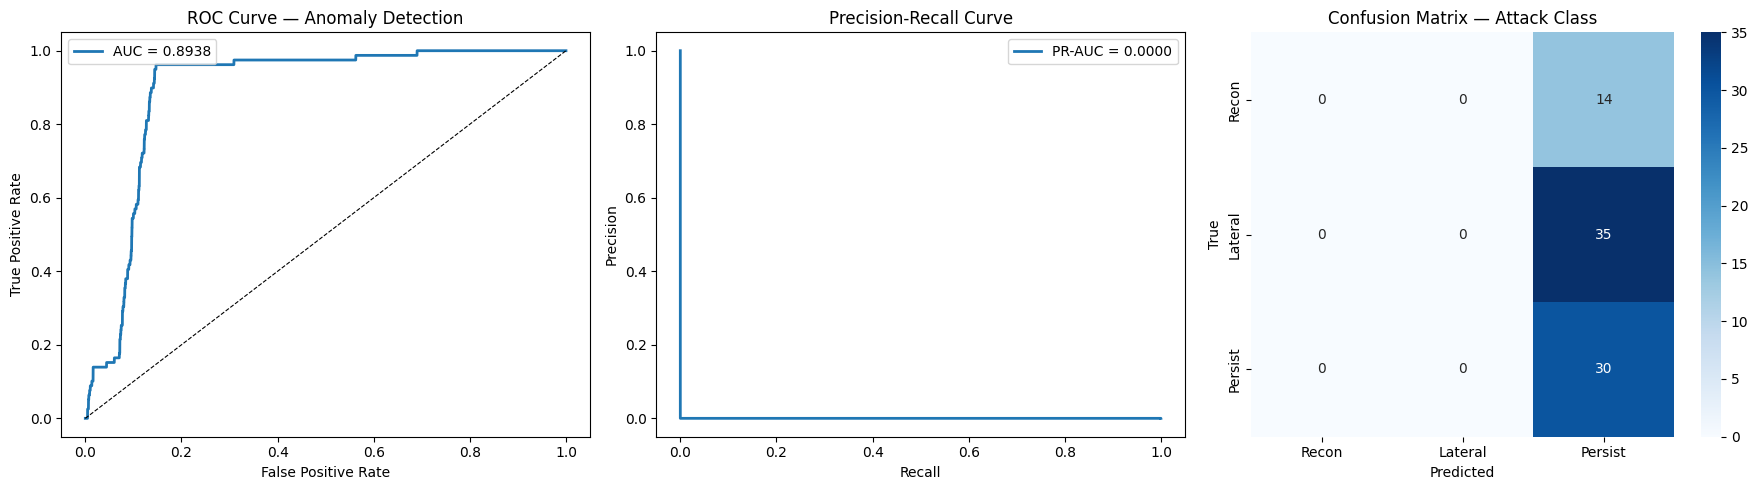

Plot disimpan ke ./parsed/evaluation_results.png


In [ ]:
checkpoint = torch.load("./parsed/best_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
best_thresh = checkpoint.get("best_thresh", 0.5)

# Warm-up memory dengan val set
model.memory.reset_memory()
with torch.no_grad():
    for src, dst, feat, ts, lbl, ei in load_window_fast(TS_TRAIN_END, TS_VAL_END):
        model(src, dst, feat, ts, ei)

all_labels = []
all_probs  = []

with torch.no_grad():
    for src, dst, feat, ts, lbl, ei in load_window_fast(TS_VAL_END, TS_MAX):
        ano_logit = model(src, dst, feat, ts, ei)
        all_labels.extend(lbl.cpu().numpy().tolist())
        all_probs.extend(torch.sigmoid(ano_logit).cpu().numpy().tolist())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
preds      = (all_probs >= best_thresh).astype(int)

print("="*60)
print("ANOMALY DETECTION — Test Set")
print("="*60)
print(classification_report(
    all_labels, preds,
    target_names=["Normal", "Anomaly"],
    digits=4
))

auroc = roc_auc_score(all_labels, all_probs)
print(f"AUROC      : {auroc:.4f}")
print(f"Threshold  : {best_thresh:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auroc:.4f}")
axes[0].plot([0,1], [0,1], "k--", lw=0.8)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(all_labels, all_probs)
axes[1].plot(rec, prec, lw=2, label=f"PR-AUC = {auc(rec, prec):.4f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("./parsed/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()

# CELL 28 - Save & Inference

In [ ]:
torch.save({
    "model_state"  : model.state_dict(),
    "optim_state"  : optimizer.state_dict(),
    "config": {
        "num_nodes"     : NUM_NODES,
        "memory_dim"    : MEMORY_DIM,
        "embed_dim"     : EMBED_DIM,
        "edge_feat_dim" : EDGE_FEAT_DIM,
        "num_classes"   : NUM_CLASSES,    # 3
        "best_threshold": best_thresh,    # Bug 5 fix: pasti terdefinisi
    },
    "history"      : history,
    "val_metrics"  : checkpoint["val_metrics"],
}, "./parsed/lognet_final.pt")
 
print(f"Model final disimpan. best_thresh = {best_thresh:.2f}")
 
# Bug 6 fix: CLASS_NAMES sesuai head output (0-indexed)
# Saat inference: prediksi head → nama kelas
CLASS_NAMES = {
    0: "Reconnaissance",
    1: "Lateral Movement",
    2: "Persistence",
}
 
def predict_log_batch(
    src_computers: list,
    dst_computers: list,
    features: np.ndarray,
    timestamps: list,
    threshold: float = best_thresh,   # Bug 5 fix: default pakai global best_thresh
) -> pd.DataFrame:
    """
    Inference pada batch log baru.
 
    Parameters
    ----------
    src_computers : list[str]  — nama komputer sumber (e.g. "C1234")
    dst_computers : list[str]  — nama komputer tujuan
    features      : np.ndarray — shape (N, 6)
    timestamps    : list[int]  — unix timestamp tiap event
    threshold     : float      — threshold anomaly score
 
    Returns
    -------
    pd.DataFrame dengan kolom:
        src_computer, dst_computer, timestamp,
        anomaly_score, is_anomaly, attack_class, attack_class_name
        
    Catatan attack_class_name:
        "Normal"           → is_anomaly == 0
        "Reconnaissance"   → is_anomaly == 1, head pred = 0
        "Lateral Movement" → is_anomaly == 1, head pred = 1
        "Persistence"      → is_anomaly == 1, head pred = 2
    """
    model.eval()
 
    src_ids = np.array([
        node_map.get(f"c_{c}", -1) for c in src_computers
    ], dtype=np.int32)
    dst_ids = np.array([
        node_map.get(f"c_{c}", -1) for c in dst_computers
    ], dtype=np.int32)
 
    valid_mask = (src_ids != -1) & (dst_ids != -1)
    if valid_mask.sum() == 0:
        print("Tidak ada node yang dikenali dalam node_map.")
        return pd.DataFrame()
 
    src_ids      = src_ids[valid_mask]
    dst_ids      = dst_ids[valid_mask]
    features     = features[valid_mask]
    timestamps_v = np.array(timestamps)[valid_mask]
 
    src_t  = torch.tensor(src_ids,      dtype=torch.long).to(DEVICE)
    dst_t  = torch.tensor(dst_ids,      dtype=torch.long).to(DEVICE)
    feat_t = torch.tensor(features,     dtype=torch.float32).to(DEVICE)
    ts_t   = torch.tensor(timestamps_v, dtype=torch.long).to(DEVICE)
    ei_t   = torch.stack([src_t, dst_t], dim=0)
 
    with torch.no_grad():
        ano_logit = model(src_t, dst_t, feat_t, ts_t, ei_t)  # ← 1 output saja

    ano_scores = torch.sigmoid(ano_logit).cpu().numpy()
    is_anomaly = (ano_scores >= threshold).astype(int)

    # Karena tidak ada class head, klasifikasi pakai heuristik sederhana
    # berdasarkan pola koneksi di batch ini
    src_arr = np.array(src_computers)[valid_mask]
    dst_arr = np.array(dst_computers)[valid_mask]

    def classify_attack_heuristic(src_arr, dst_arr, is_anomaly):
        """
        Rule-based fallback karena model tidak punya class head.
        - Reconnaissance : satu src → banyak dst unik
        - Lateral Movement: src berganti-ganti (berpindah mesin)
        - Persistence     : src dan dst sama berulang
        """
        from collections import Counter
        cls_preds = []
        src_dst_count = Counter(zip(src_arr, dst_arr))

        for i, (s, d, is_atk) in enumerate(zip(src_arr, dst_arr, is_anomaly)):
            if not is_atk:
                cls_preds.append(-1)  # Normal, tidak diklasifikasi
                continue

            # Hitung berapa banyak dst unik dari src ini
            dst_from_src = [dst for src, dst in zip(src_arr, dst_arr) if src == s]
            unique_dst = len(set(dst_from_src))

            # Hitung berapa kali pasangan (src, dst) ini muncul
            repeat_count = src_dst_count[(s, d)]

            if unique_dst >= 3:
                cls_preds.append(0)  # Reconnaissance — sebar ke banyak target
            elif repeat_count >= 3:
                cls_preds.append(2)  # Persistence — koneksi berulang ke target sama
            else:
                cls_preds.append(1)  # Lateral Movement — default
        
        return np.array(cls_preds)

    cls_preds = classify_attack_heuristic(src_arr, dst_arr, is_anomaly)

    result = pd.DataFrame({
        "src_computer"     : src_arr,
        "dst_computer"     : dst_arr,
        "timestamp"        : timestamps_v,
        "anomaly_score"    : ano_scores,
        "is_anomaly"       : is_anomaly,
        "attack_class"     : cls_preds,
        "attack_class_name": [
            CLASS_NAMES[c] if (a and c >= 0) else "Normal"
            for c, a in zip(cls_preds, is_anomaly)
        ],
    })
 
    return result
 
 
# Quick test inference
print("\nTest inference dengan 3 event dummy (dari attack events)...")
sample_edges = pd.read_parquet(
    "./parsed/auth_edges.parquet",
    columns=["src_id","dst_id","timestamp","label"]
)
sample_edges = sample_edges[sample_edges["label"]==1].head(3)
 
reverse_map = {v: k for k, v in node_map.items()}
src_names   = [reverse_map.get(i, "UNKNOWN").replace("c_","")
               for i in sample_edges["src_id"]]
dst_names   = [reverse_map.get(i, "UNKNOWN").replace("c_","")
               for i in sample_edges["dst_id"]]
dummy_feats = np.zeros((len(sample_edges), 6), dtype=np.float32)
dummy_ts    = sample_edges["timestamp"].tolist()
 
result_df = predict_log_batch(src_names, dst_names, dummy_feats, dummy_ts)
print(result_df.to_string())
print("\nInference selesai. Model siap digunakan.")

SyntaxError: invalid syntax (534687739.py, line 1)